# Loan Repayment Risk Scoring with Full Pipeline Automation

## Internship Project

**Domain:** Finance / FinTech

**Objective:** This project aims to predict the loan default risk of borrowers using machine learning techniques. The system analyzes financial and credit-related attributes and classifies applicants into low-risk and high-risk categories. The final model is deployed through a Streamlit web application for real-time prediction.


# Step 1 : Import Data

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully')

Libraries imported successfully


Load the Lending Club loan dataset into a Pandas DataFrame for further analysis.

In [149]:
df = pd.read_csv(
    'accepted_2007_to_2018Q4.csv',
    nrows=200000,
    low_memory=False
)

print('Dataset loaded successfully')

Dataset loaded successfully


In [150]:
# target filtering
## Filter the dataset to keep only Fully Paid and Charged Off loan records and check their class distribution.
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])] 
df['loan_status'].value_counts()

loan_status
Fully Paid     140992
Charged Off     35090
Name: count, dtype: int64

In [151]:
# default rate 
# # Calculate and display the overall loan default rate (Charged Off percentage) in the filtered dataset.
default_rate = (df['loan_status'] == 'Charged Off').mean() * 100 
print(default_rate)

19.928215263343215


## Step 2: Data cleaning

In [152]:
#Check the shape of the dataset to determine the number of rows and columns.
df.shape

(176082, 151)

In [153]:
## Display first 5 rows of the dataset.
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [154]:
## Display column names.
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=151)

In [155]:
## Display dataset information.
df.info()

<class 'pandas.DataFrame'>
Index: 176082 entries, 0 to 199999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), str(36)
memory usage: 241.7 MB


In [156]:
## Remove extra spaces from column names.
df.columns = df.columns.str.strip()

In [157]:
## Check missing values in the dataset.
df.isna().sum()

id                            0
member_id                176082
loan_amnt                     0
funded_amnt                   0
funded_amnt_inv               0
                          ...  
settlement_status        170305
settlement_date          170305
settlement_amount        170305
settlement_percentage    170305
settlement_term          170305
Length: 151, dtype: int64

In [158]:
# columns with highest missing values

missing = df.isnull().sum().sort_values(ascending=False)

missing.head(20)

member_id                                     176082
sec_app_num_rev_accts                         176082
sec_app_open_act_il                           176082
sec_app_inq_last_6mths                        176082
sec_app_open_acc                              176082
sec_app_mort_acc                              176082
next_pymnt_d                                  176082
sec_app_collections_12_mths_ex_med            176082
sec_app_chargeoff_within_12_mths              176082
sec_app_earliest_cr_line                      176082
revol_bal_joint                               176082
sec_app_revol_util                            176082
sec_app_fico_range_high                       176082
sec_app_fico_range_low                        176082
sec_app_mths_since_last_major_derog           176082
desc                                          176072
dti_joint                                     175682
annual_inc_joint                              175681
verification_status_joint                     

In [159]:
# missing percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False).head(20)

member_id                                     100.000000
sec_app_num_rev_accts                         100.000000
sec_app_open_act_il                           100.000000
sec_app_inq_last_6mths                        100.000000
sec_app_open_acc                              100.000000
sec_app_mort_acc                              100.000000
next_pymnt_d                                  100.000000
sec_app_collections_12_mths_ex_med            100.000000
sec_app_chargeoff_within_12_mths              100.000000
sec_app_earliest_cr_line                      100.000000
revol_bal_joint                               100.000000
sec_app_revol_util                            100.000000
sec_app_fico_range_high                       100.000000
sec_app_fico_range_low                        100.000000
sec_app_mths_since_last_major_derog           100.000000
desc                                           99.994321
dti_joint                                      99.772833
annual_inc_joint               

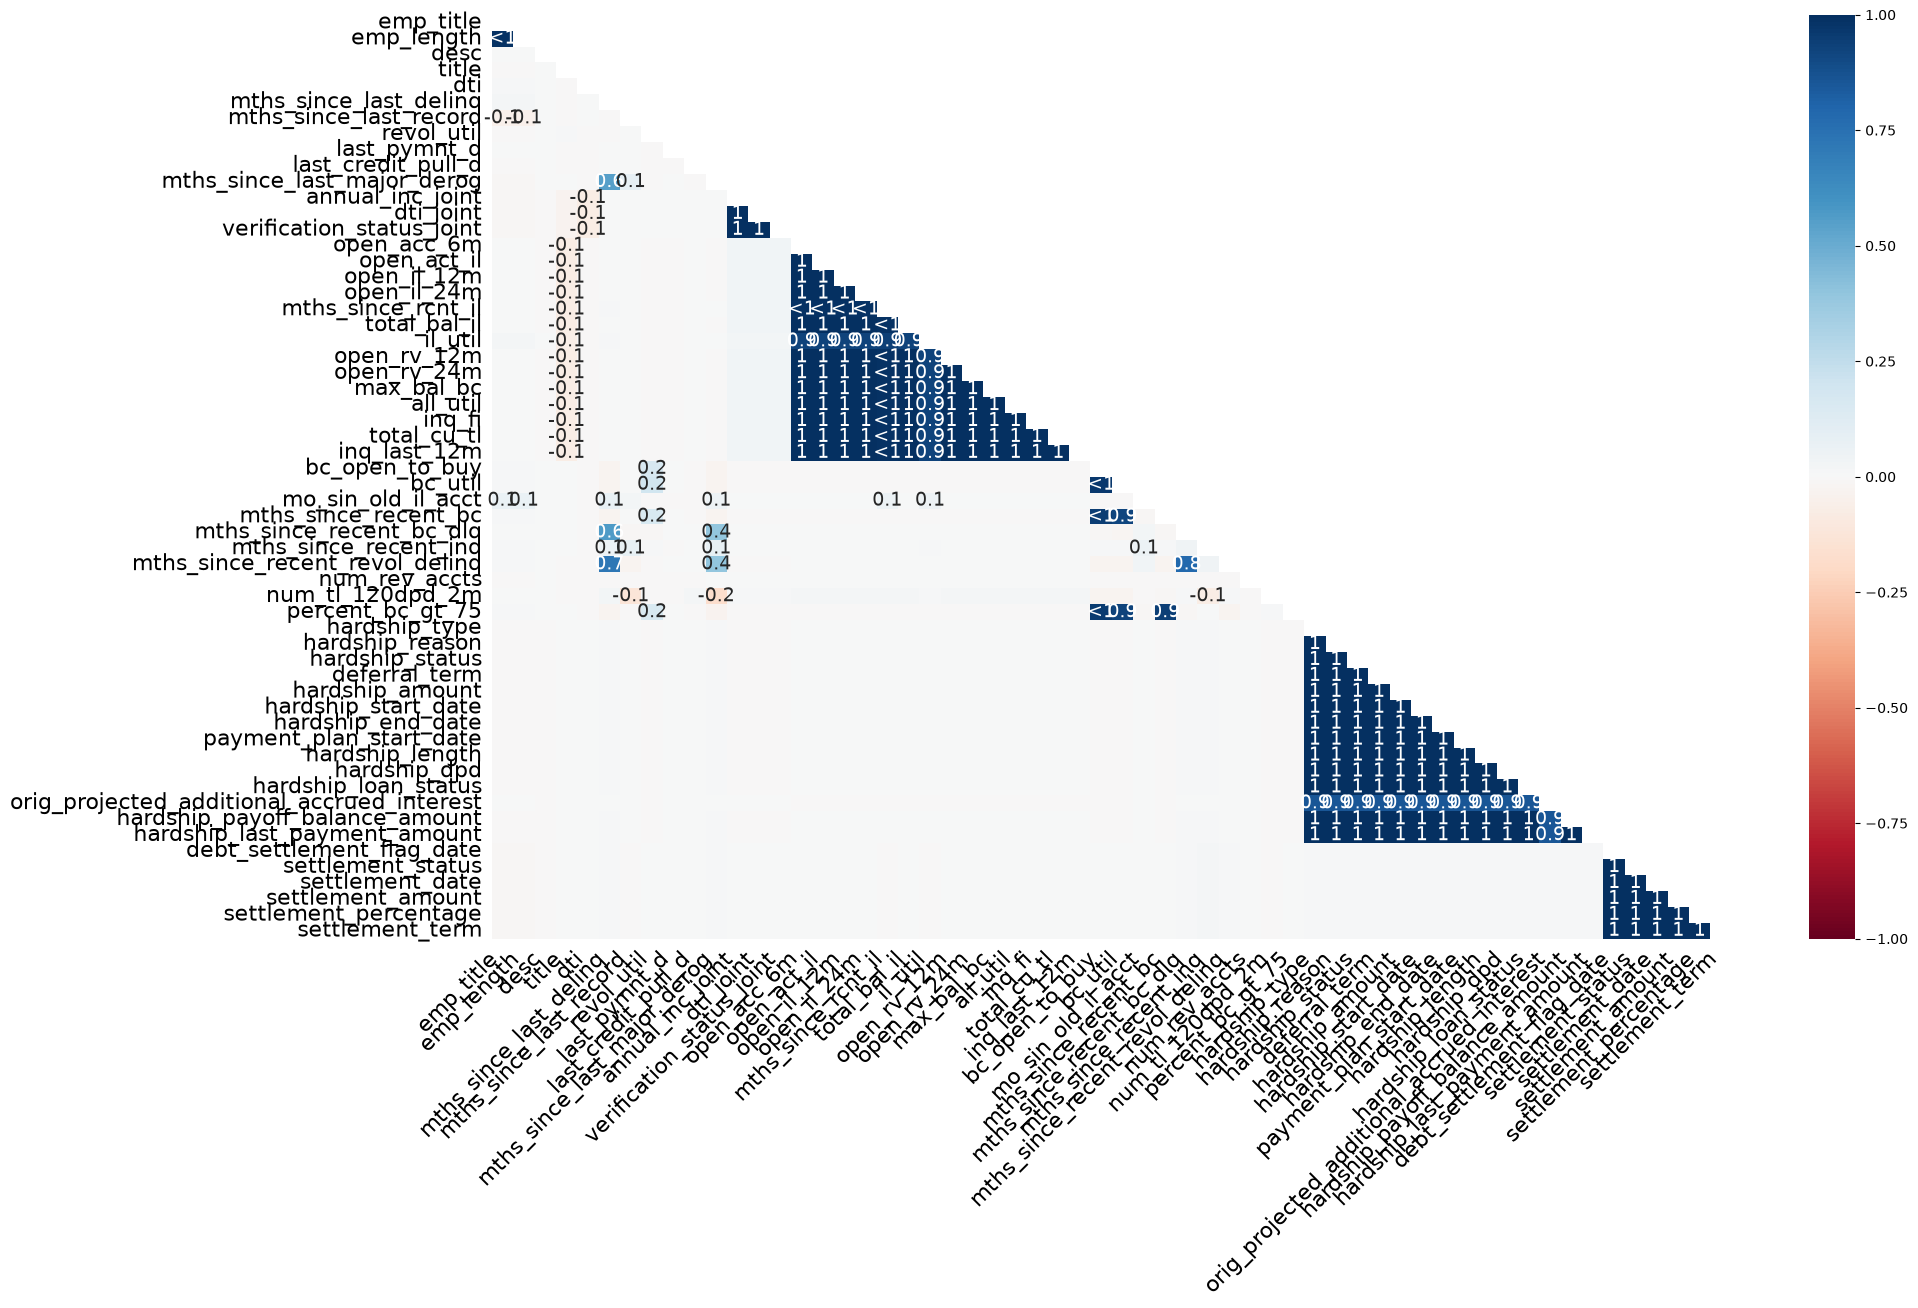

In [160]:

# Visualize missing values using a heatmap.
import missingno as msno

msno.heatmap(df)
plt.show()

In [161]:
# checking duplicate rows

print('Duplicate Rows :', df.duplicated().sum())

Duplicate Rows : 0


In [162]:
# checking data types count

df.dtypes.value_counts()

float64    114
str         36
int64        1
Name: count, dtype: int64

In [163]:
# checking remaining missing values
df.isna().sum().sort_values(ascending=False).head(15)

member_id                              176082
sec_app_num_rev_accts                  176082
sec_app_open_act_il                    176082
sec_app_inq_last_6mths                 176082
sec_app_open_acc                       176082
sec_app_mort_acc                       176082
next_pymnt_d                           176082
sec_app_collections_12_mths_ex_med     176082
sec_app_chargeoff_within_12_mths       176082
sec_app_earliest_cr_line               176082
revol_bal_joint                        176082
sec_app_revol_util                     176082
sec_app_fico_range_high                176082
sec_app_fico_range_low                 176082
sec_app_mths_since_last_major_derog    176082
dtype: int64

In [164]:
# drop columns with >40% missing values 
null_percent = (df.isnull().sum() / len(df)) * 100 
drop_cols = null_percent[null_percent > 40].index 
df.drop(columns = drop_cols, inplace = True) 
df.shape

(176082, 93)

<Figure size 1000x500 with 0 Axes>

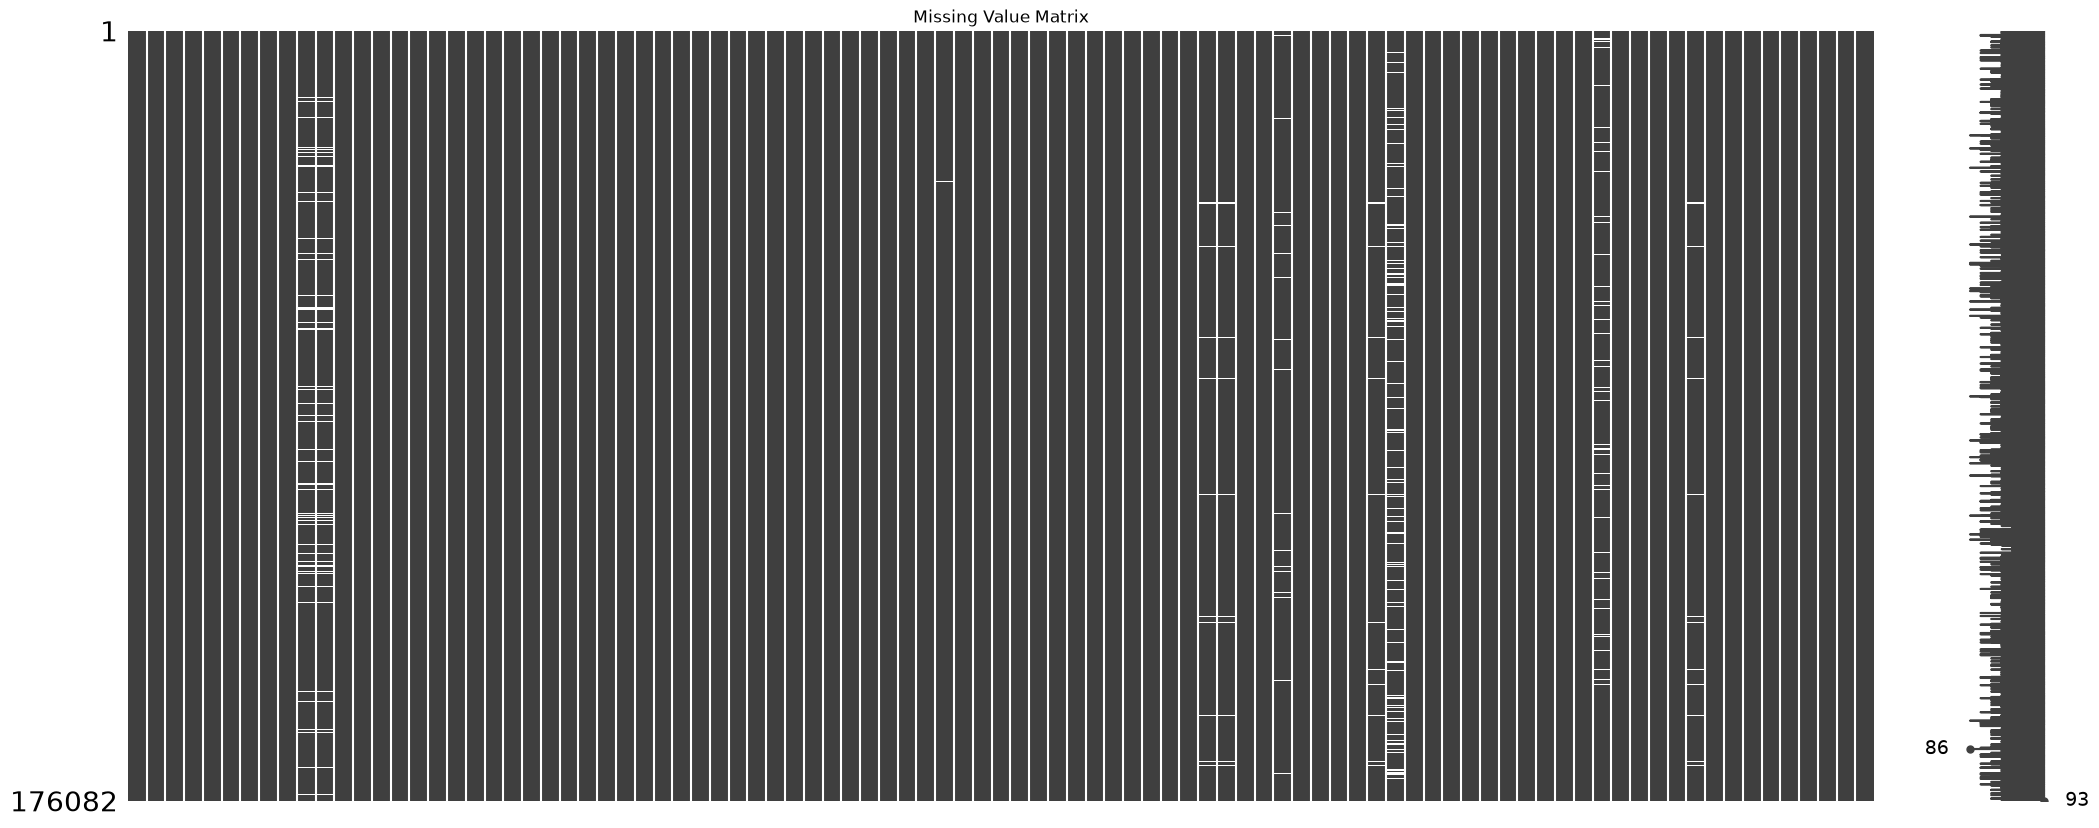

In [165]:
## Display missing value matrix.
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
msno.matrix(df)
plt.title('Missing Value Matrix')
plt.show()

In [166]:
# numerical imputation

num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [167]:
# Remove identifier and leakage columns
df = df.drop(columns=['id', 'funded_amnt_inv', 'total_pymnt', 'recoveries'], errors='ignore')

In [168]:
# categorical imputation

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Hp\AppData\Local\Temp\ipykernel_17868\1024796218.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [169]:
# separate input and output
# Final 10 features selected for training and deployment

final_features = [
    'loan_amnt',
    'funded_amnt',
    'int_rate',
    'annual_inc',
    'fico_range_low',
    'fico_range_high',
    'revol_bal',
    'tot_cur_bal',
    'total_rev_hi_lim',
    'dti'
]

x = df[final_features]
y = df['loan_status']

In [170]:
# target encoding 
y = y.map({'Fully Paid': 0, 'Charged Off': 1}) 
y.value_counts()

loan_status
0    140992
1     35090
Name: count, dtype: int64

In [171]:
# Default rate and class imbalance

default_rate = (y == 1).mean() * 100

print('Default Rate (%):', round(default_rate, 2))
print('\nClass Distribution:')
print(y.value_counts())
print('\nClass Distribution (%):')
print(round(y.value_counts(normalize=True) * 100, 2))

Default Rate (%): 19.93

Class Distribution:
loan_status
0    140992
1     35090
Name: count, dtype: int64

Class Distribution (%):
loan_status
0    80.07
1    19.93
Name: proportion, dtype: float64


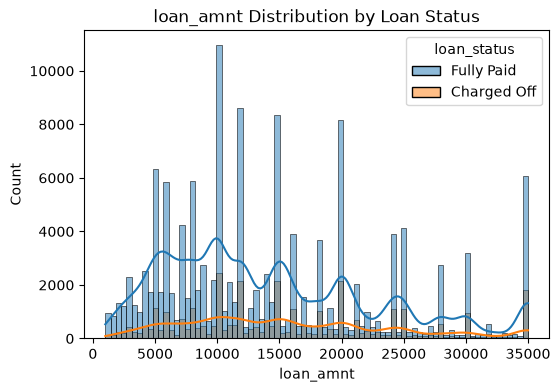

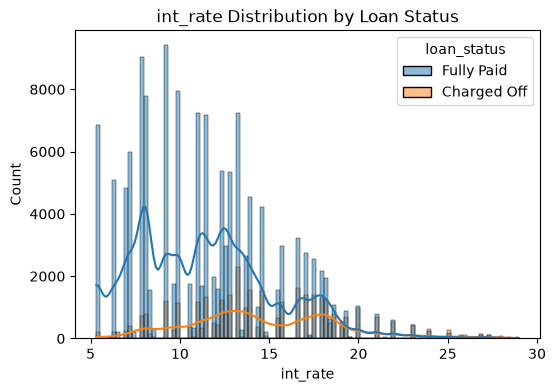

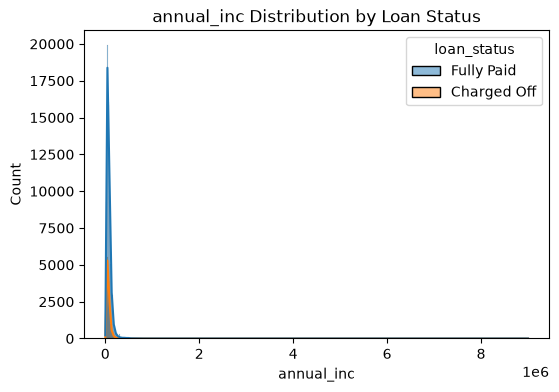

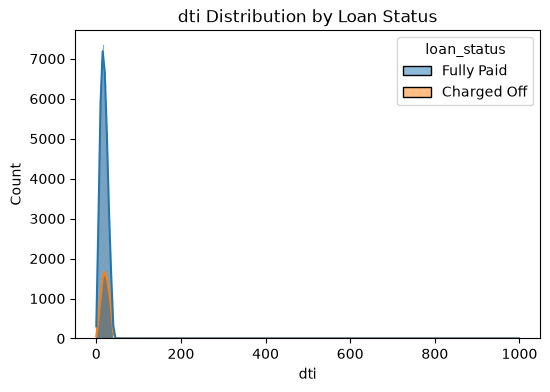

In [172]:
## Plot feature distributions by loan status.
import seaborn as sns

cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='loan_status', kde=True)
    plt.title(f'{col} Distribution by Loan Status')
    plt.show()

##  Step 3: Exploratory data analysis

Exploratory Data Analysis is performed to identify patterns, trends, and distributions in the dataset. Visualizations help in understanding loan status distribution, financial behavior of borrowers, and relationships among important variables.

In [173]:
## Check basic statistics of input features.
x.describe()

,loan_amnt,funded_amnt,int_rate,annual_inc,fico_range_low,fico_range_high,revol_bal,tot_cur_bal,total_rev_hi_lim,dti
count,176082.000000,176082.000000,176082.000000,1.760820e+05,176082.000000,176082.000000,176082.000000,1.760820e+05,1.760820e+05,176082.000000
mean,14619.829398,14619.829398,12.109350,7.749671e+04,694.528231,698.528362,17363.201645,1.398771e+05,3.408020e+04,18.911066
std,8616.073483,8616.073483,4.231768,8.165976e+04,31.060266,31.060901,24228.613960,1.583053e+05,3.536807e+04,9.180775
min,1000.000000,1000.000000,5.320000,0.000000e+00,660.000000,664.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,8000.000000,8000.000000,8.380000,4.600000e+04,670.000000,674.000000,6198.000000,3.022725e+04,1.430000e+04,12.310000
50%,12425.000000,12425.000000,11.990000,6.500000e+04,685.000000,689.000000,11481.000000,7.801100e+04,2.460000e+04,18.340000
75%,20000.000000,20000.000000,14.650000,9.200000e+04,710.000000,714.000000,20652.000000,2.065975e+05,4.200000e+04,25.090000
max,35000.000000,35000.000000,28.990000,9.000000e+06,845.000000,850.000000,924579.000000,3.726495e+06,1.165700e+06,999.000000


In [174]:
## Check feature matrix shape.
x.shape

(176082, 10)

In [175]:
# Display top class frequencies.
y.value_counts().head(10)

loan_status
0    140992
1     35090
Name: count, dtype: int64

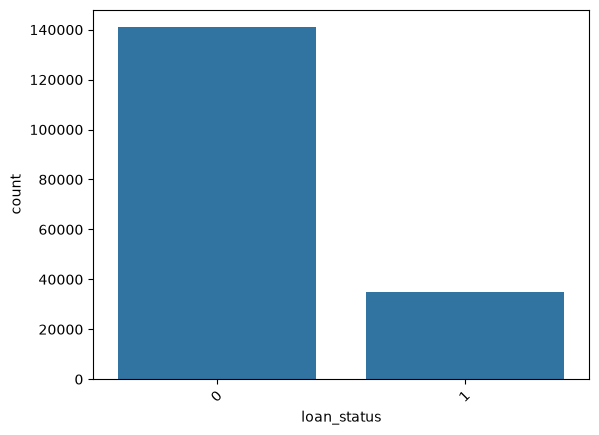

In [176]:
#Loan status plot
sns.countplot(x = y)
plt.xticks(rotation = 45);
#This shows how many loans are in each loan status category.

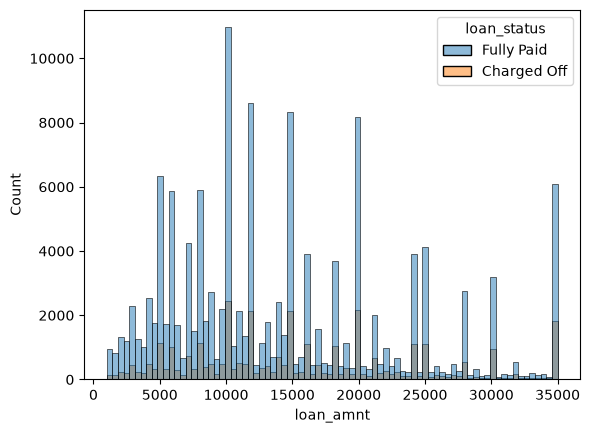

In [177]:
# Plot loan amount distribution by loan status.
sns.histplot(data=df, x='loan_amnt', hue='loan_status')
plt.show()

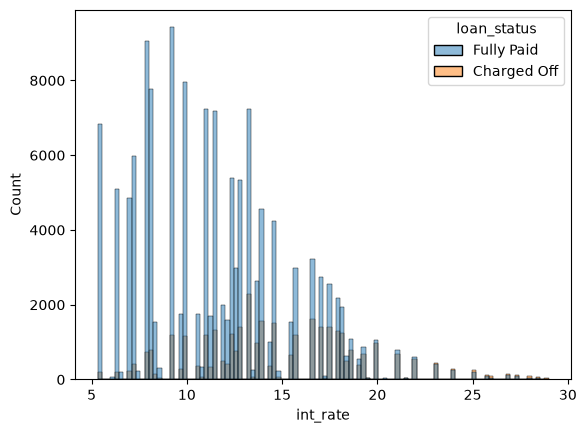

In [178]:
sns.histplot(data = df, x = 'int_rate', hue = 'loan_status')
plt.show()


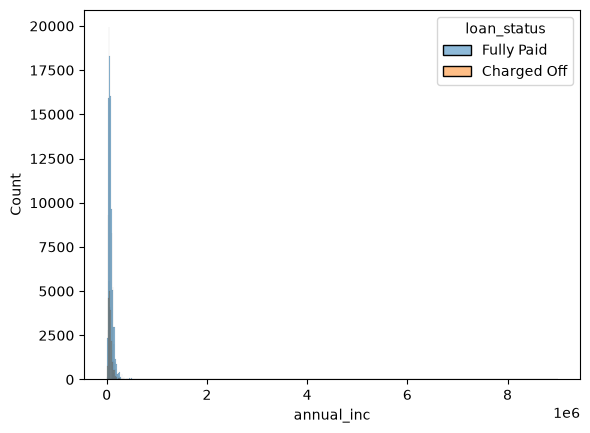

In [179]:
# Plot annual income distribution by loan status.
sns.histplot(data=df, x='annual_inc', hue='loan_status')
plt.show()


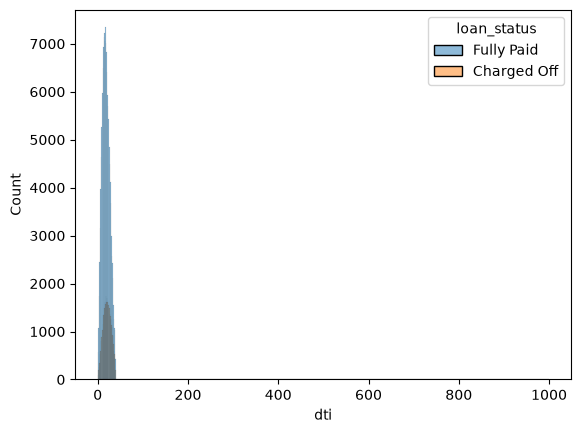

In [180]:
sns.histplot(data = df, x = 'dti', hue = 'loan_status')
plt.show()

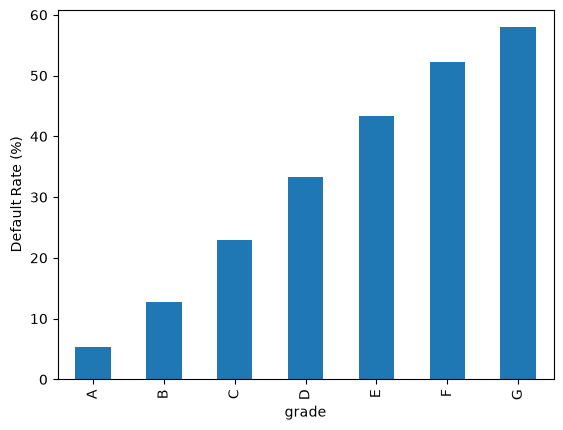

In [181]:
# Plot default rate by loan grade.
grade_default = pd.crosstab(df['grade'], df['loan_status'], normalize='index') * 100

grade_default['Charged Off'].plot(kind='bar')

plt.ylabel('Default Rate (%)')
plt.show()


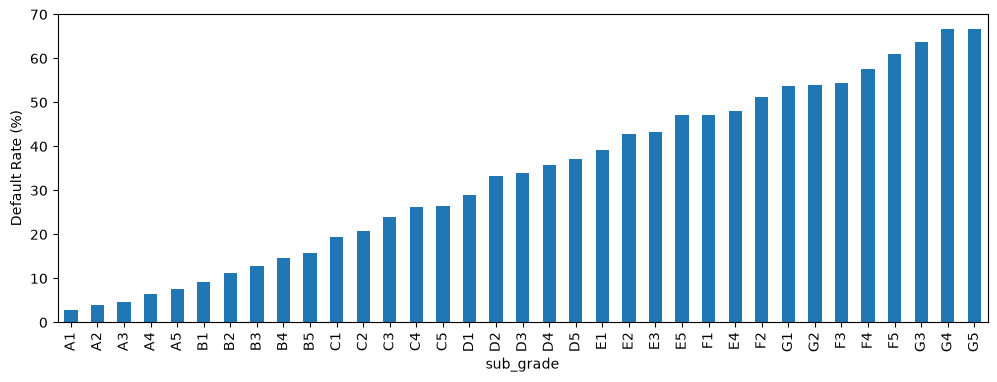

In [260]:
## Calculates the default rate for each sub-grade and plots it as a bar chart
subgrade_default = pd.crosstab(df['sub_grade'], df['loan_status'], normalize = 'index') * 100

subgrade_default['Charged Off'].sort_values().plot(kind = 'bar', figsize = (12,4))

plt.ylabel('Default Rate (%)')
plt.show()

## Step 4:  Outlier Detection and Removal

Outliers in numerical features are identified and treated to reduce the impact of extreme values on model performance. This helps improve the stability and generalization capability of the model.

In [183]:
x.dtypes

loan_amnt           float64
funded_amnt         float64
int_rate            float64
annual_inc          float64
fico_range_low      float64
fico_range_high     float64
revol_bal           float64
tot_cur_bal         float64
total_rev_hi_lim    float64
dti                 float64
dtype: object

In [184]:
# Select numerical columns for outlier analysis.
num_cols = ['loan_amnt', 'annual_inc', 'dti', 'int_rate']

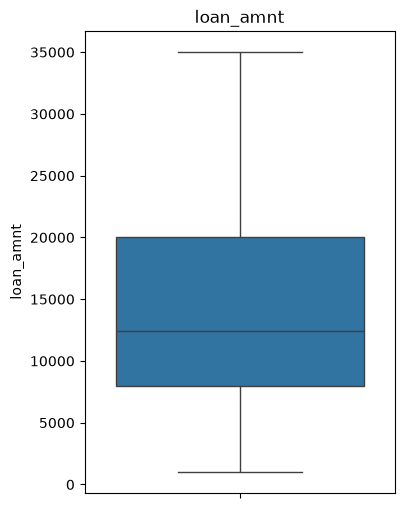

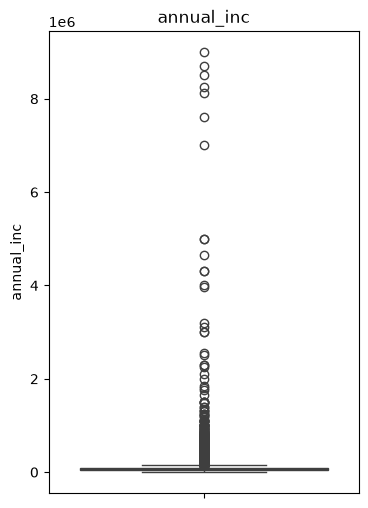

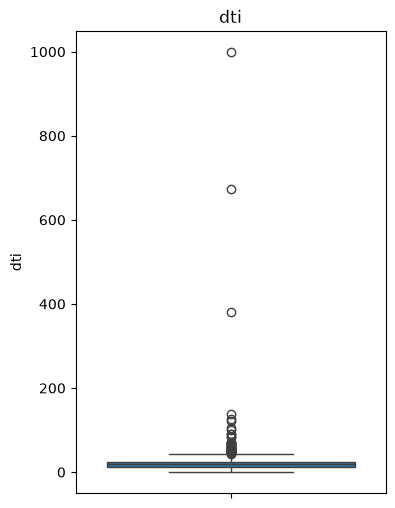

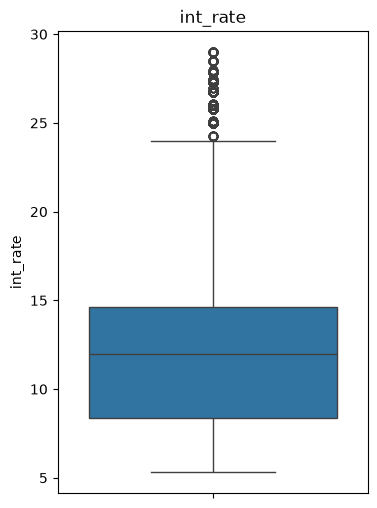

In [185]:
# Plot boxplots for outlier detection.
for col in num_cols:
    plt.figure(figsize=(4,6))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

In [186]:
# Remove high-cardinality categorical columns and check updated feature shape.
drop_high_card = ['emp_title', 'title']

x = x.drop(columns=[c for c in drop_high_card if c in x.columns])

x.shape

(176082, 10)

In [187]:
# Apply frequency encoding to categorical location features.
for col in ['zip_code', 'addr_state']:
    if col in x.columns:
        freq = x[col].value_counts(normalize=True)
        x[col] = x[col].map(freq)

In [188]:
# Encode categorical features and check updated feature shape.
encode_cols = ['grade',
               'sub_grade',
               'home_ownership',
               'verification_status',
               'purpose',
               'term']

encode_cols = [c for c in encode_cols if c in x.columns]

x = pd.get_dummies(x,
                   columns=encode_cols,
                   drop_first=True)

x.shape

(176082, 10)

In [189]:
# Store the encoded feature column order for deployment.
col_order_ohe = x.columns.tolist()

In [190]:
print(x.shape)

(176082, 10)


In [191]:
# remove remaining string columns

obj_cols = x.select_dtypes(include='object').columns
print(obj_cols)

Index([], dtype='str')


In [192]:
# Remove remaining object-type columns and check updated feature shape.
x = x.drop(columns=obj_cols)

x.shape

(176082, 10)

In [193]:
# isolation forest for outlier removal

In [194]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05,
                      random_state=0)

In [195]:
# Detect outliers using Isolation Forest.
clean = iso.fit_predict(x)


In [196]:
# Display outlier prediction labels.
clean

array([1, 1, 1, ..., 1, 1, 1], shape=(176082,))

In [197]:
# Remove detected outliers from features and target.
x = x[clean == 1]
y = y[clean == 1]


In [198]:
x.shape

(167277, 10)

In [199]:
y.shape

(167277,)

In [200]:
y.value_counts()

loan_status
0    133462
1     33815
Name: count, dtype: int64

# Step 5 — Data balancing / Resampling

In [201]:
# Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=0
)

In [202]:
## Check training data shape.
x_train.shape, y_train.shape

((133821, 10), (133821,))

In [203]:
#  Sampling (Over Sampling)

# Import SMOTE for class balancing.
from imblearn.over_sampling import SMOTE

In [204]:
# Initialize SMOTE with selected parameters.
smote = SMOTE(k_neighbors=5,
              random_state=0)

In [205]:
# Check missing values in training data
x_train.isna().sum().sort_values(ascending=False).head(20)

loan_amnt           0
funded_amnt         0
int_rate            0
annual_inc          0
fico_range_low      0
fico_range_high     0
revol_bal           0
tot_cur_bal         0
total_rev_hi_lim    0
dti                 0
dtype: int64

In [206]:
# Fill missing values with median
x_train = x_train.fillna(x_train.median(numeric_only=True))
x_test = x_test.fillna(x_train.median(numeric_only=True))

In [207]:
# Balance the training data using SMOTE.
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [208]:
y_train_res.value_counts()

loan_status
1    106769
0    106769
Name: count, dtype: int64

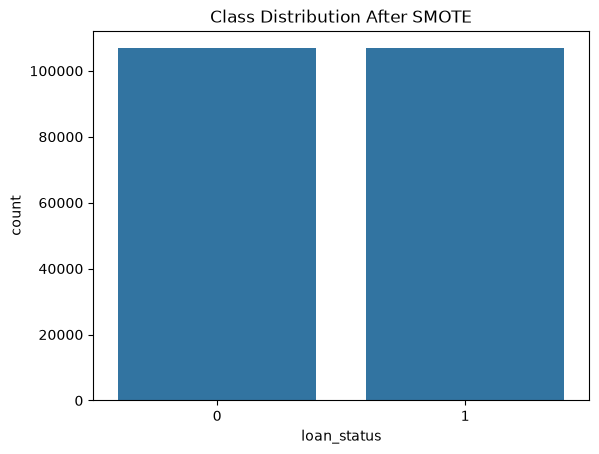

In [209]:
# Plot class distribution after SMOTE.
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train_res)
plt.title('Class Distribution After SMOTE')
plt.show()

# Step 6 — Feature selection / Dimensionality reduction

In [210]:
# convert boolean columns to integer

x_train_res = x_train_res.astype(int)

x_test = x_test.astype(int)

In [211]:
# make values non-negative

x_train_pos = x_train_res - x_train_res.min()

x_test_pos = x_test - x_train_res.min()

In [212]:
from sklearn.feature_selection import SelectKBest, chi2

In [213]:
# Initialize SelectKBest for feature selection.
skf = SelectKBest(k=10,
                  score_func=chi2)

In [214]:
# Select important features for training and testing.
x_train_new = skf.fit_transform(x_train_pos, y_train_res)

x_test_new = skf.transform(x_test_pos)

In [215]:
# Check selected feature shapes.
x_train_new.shape
x_test_new.shape

(33456, 10)

In [216]:
# Display selected important features.
selected_features = x.columns[skf.get_support()]

selected_features

Index(['loan_amnt', 'funded_amnt', 'int_rate', 'annual_inc', 'fico_range_low',
       'fico_range_high', 'revol_bal', 'tot_cur_bal', 'total_rev_hi_lim',
       'dti'],
      dtype='str')

In [217]:
x_train_new.shape

(213538, 10)

# Step 7 — Cross validation

Cross validation is performed to evaluate the model on multiple data splits so that the selected model gives stable and reliable performance on unseen data.

In [218]:

# Step 7 Cross Validation

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [219]:
# Initialize Logistic Regression for cross validation.
lr_cv = LogisticRegression(
    max_iter=1000,
    random_state=0
)

In [220]:
# Perform 3-fold cross validation for Logistic Regression.
cv_scores = cross_val_score(
    lr_cv,
    x_train_new,
    y_train_res,
    cv=3,
    scoring='accuracy'
)

# Step 8 — Feature Scaling

Feature scaling is performed to bring all numerical features to a similar range so that the model learns fairly from every feature and training becomes more stable and efficient.

In [221]:

from sklearn.preprocessing import StandardScaler

In [222]:
sc = StandardScaler()


In [223]:
# Scale only the selected 10 features

# Fit on training data and transform
x_train_new = sc.fit_transform(x_train_new)

# Transform test data
x_test_new = sc.transform(x_test_new)
print(x_train_new.shape)
print(x_test_new.shape)

(213538, 10)
(33456, 10)


In [224]:
print(x_train_new.shape)
print(x_test_new.shape)

(213538, 10)
(33456, 10)


# Step 9 — Algorithms and Hyperparameter Tuning

In this step, different machine learning algorithms are tested and their hyperparameters are adjusted to find the model that provides the best performance and accuracy.

In [225]:
# Step 9: Import Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [226]:
# Logistic Regression Model

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train_new, y_train_res)

lr_pred = lr.predict(x_test_new)

lr_acc = accuracy_score(y_test, lr_pred)

print('Logistic Regression Accuracy:', lr_acc)

Logistic Regression Accuracy: 0.6689084170253468


In [227]:
# Random Forest Model

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train_new, y_train_res)

rf_pred = rf.predict(x_test_new)

rf_acc = accuracy_score(y_test, rf_pred)

print('Random Forest Accuracy:', rf_acc)

Random Forest Accuracy: 0.7577116212338594


In [228]:
# XGBoost Model

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb.fit(x_train_new, y_train_res)

xgb_pred = xgb.predict(x_test_new)

xgb_acc = accuracy_score(y_test, xgb_pred)

print('XGBoost Accuracy:', xgb_acc)

XGBoost Accuracy: 0.765512912482066


In [229]:
# Accuracy Comparison Table

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc]
})

comparison = comparison.sort_values(by='Accuracy', ascending=False)

print(comparison)

                 Model  Accuracy
2              XGBoost  0.765513
1        Random Forest  0.757712
0  Logistic Regression  0.668908


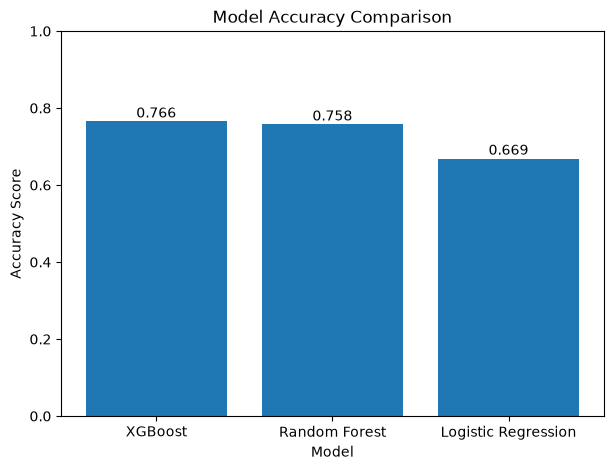

In [230]:
# Accuracy Comparison Chart

plt.figure(figsize=(7,5))

plt.bar(comparison['Model'], comparison['Accuracy'])

plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.title('Model Accuracy Comparison')

plt.ylim(0, 1)

for i, v in enumerate(comparison['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.show()

In [231]:
# Select Best Model

best_model_name = comparison.iloc[0]['Model']

print('Best Model:', best_model_name)

if best_model_name == 'Logistic Regression':
    best_model = lr

elif best_model_name == 'Random Forest':
    best_model = rf

else:
    best_model = xgb

Best Model: XGBoost


In [232]:
# Evaluation of Best Model

best_pred = best_model.predict(x_test_new)

print('Best Model Accuracy:', accuracy_score(y_test, best_pred))

print('\nClassification Report:\n')
print(classification_report(y_test, best_pred))

print('\nConfusion Matrix:\n')
print(confusion_matrix(y_test, best_pred))

Best Model Accuracy: 0.765512912482066

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.86     26693
           1       0.39      0.30      0.34      6763

    accuracy                           0.77     33456
   macro avg       0.61      0.59      0.60     33456
weighted avg       0.74      0.77      0.75     33456


Confusion Matrix:

[[23579  3114]
 [ 4731  2032]]


In [233]:
# Parameter Grid for RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [234]:
# RandomizedSearchCV with 3-Fold Cross Validation
# Randomly tests different hyperparameter combinations using cross-validation to find the best settings
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

grid = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [235]:
grid.fit(x_train_new, y_train_res)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instanc

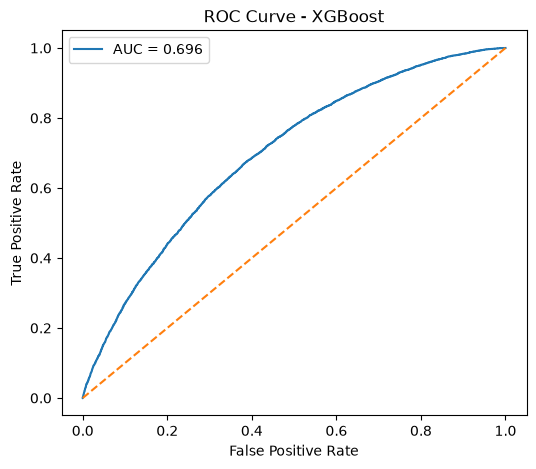

In [236]:
# ROC Curve of Best Model

best_prob = best_model.predict_proba(x_test_new)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, best_prob)
auc_score = roc_auc_score(y_test, best_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')

plt.legend()

plt.show()

In [237]:
grid.best_params_

{'subsample': 0.7,
 'n_estimators': 200,
 'max_depth': 6,
 'learning_rate': 0.2,
 'colsample_bytree': 0.9}

In [238]:
grid.best_score_

np.float64(0.7983130192699228)

In [239]:
best_model = grid.best_estimator_

# Step 10 — Model Building

In [240]:
best_model = grid.best_estimator_

best_model.fit(x_train_new, y_train_res)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [241]:
# XGBoost Feature Importance

feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

            Feature  Importance
4    fico_range_low    0.279773
2          int_rate    0.256532
5   fico_range_high    0.245654
1       funded_amnt    0.069732
0         loan_amnt    0.046298
3        annual_inc    0.026996
9               dti    0.026053
7       tot_cur_bal    0.017738
8  total_rev_hi_lim    0.015933
6         revol_bal    0.015291


# Step 11 — Predictions

In [242]:
y_pred = best_model.predict(x_test_new)

In [243]:
# Accuracy 
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print('Accuracy :', accuracy)

Accuracy : 0.7652737924438068


In [244]:
# classification_report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86     26693
           1       0.39      0.29      0.33      6763

    accuracy                           0.77     33456
   macro avg       0.61      0.59      0.60     33456
weighted avg       0.74      0.77      0.75     33456



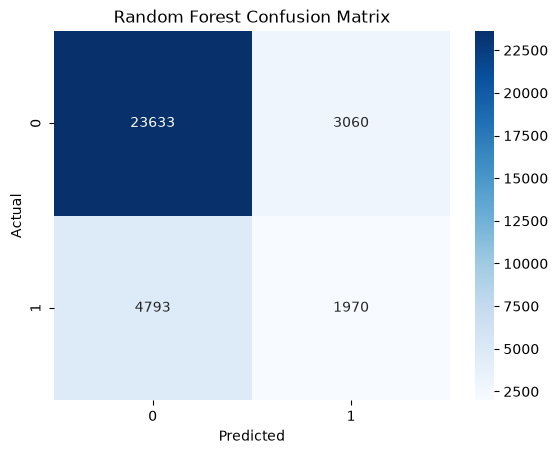

In [245]:
# confusion_matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot = True,
            fmt = 'd',
            cmap = 'Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

In [246]:
# Import functions for Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, auc


In [247]:
# Predicted probabilities for the positive class
y_prob = grid.predict_proba(x_test_new)[:,1]

In [248]:
# Calculate precision and recall values for different thresholds
precision, recall, _ = precision_recall_curve(y_test, y_prob)

In [249]:
# Calculate area under the Precision-Recall curve
pr_auc = auc(recall, precision)

In [250]:
# Print PR AUC score
print('PR AUC:', round(pr_auc, 4))

PR AUC: 0.3511


In [251]:
# Tests different classification thresholds and counts the predicted positive cases
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    print('Threshold:', t, '| Predicted Defaults:', preds.sum())

Threshold: 0.3 | Predicted Defaults: 12877
Threshold: 0.4 | Predicted Defaults: 8346
Threshold: 0.5 | Predicted Defaults: 5030
Threshold: 0.6 | Predicted Defaults: 2518
Threshold: 0.7 | Predicted Defaults: 1002


In [252]:
# Feature importance (model explainability)

import pandas as pd
import matplotlib.pyplot as plt

In [253]:

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': grid.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Print values
print(feature_importance)

            Feature  Importance
4    fico_range_low    0.279773
2          int_rate    0.256532
5   fico_range_high    0.245654
1       funded_amnt    0.069732
0         loan_amnt    0.046298
3        annual_inc    0.026996
9               dti    0.026053
7       tot_cur_bal    0.017738
8  total_rev_hi_lim    0.015933
6         revol_bal    0.015291


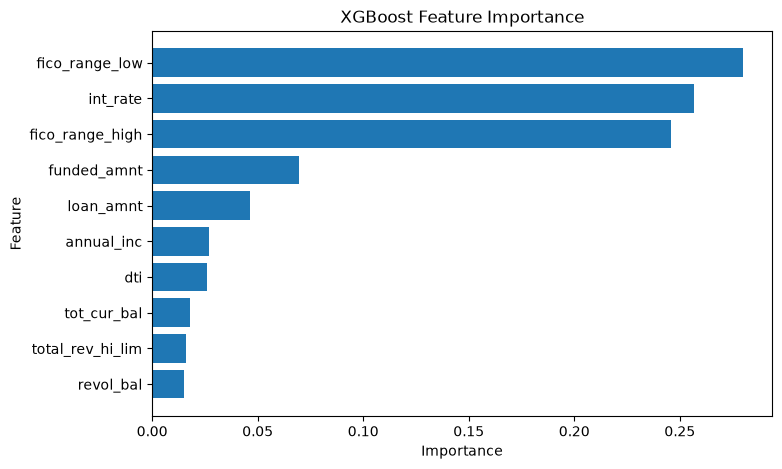

In [254]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [255]:
## Displays the best hyperparameter combination found during tuning
grid.best_params_

{'subsample': 0.7,
 'n_estimators': 200,
 'max_depth': 6,
 'learning_rate': 0.2,
 'colsample_bytree': 0.9}

In [256]:
## Returns the best-performing model found during hyperparameter tuning
grid.best_estimator_

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Step 12 — Deployment / Serialization

In [257]:
import joblib

In [258]:
# Save the final trained XGBoost model
joblib.dump(xgb, 'xgb_final_model.pkl')

['xgb_final_model.pkl']

In [259]:
# Save the scaler
joblib.dump(sc, 'xgb_final_scaler.pkl')

['xgb_final_scaler.pkl']